# Assignment 2: Probability Models Comparison  
## Probability Distributions  

A probability distribution lists the possible outcomes that a random variable can take and the probability associated with each value, where a random variable (or phenomenon) is a function that assigns a numerical value to each point in the sample space.

They can be broadly classified into:  
- **Discrete distributions**: defined on countable sets. The outcomes are the distinct, separate values that the random variable can assume, usually integers.
$$
P(X = x_i) \quad \text{for discrete random variables,}
$$
- **Continuous distributions**: defined on intervals of real numbers rather than individual values.
$$
f(x) \quad \text{for continuous random variables.}
$$  

For this assignment, we chose to work with the **Poisson** and the **Exponential** distributions.

In [12]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt  
from scipy.stats import poisson, expon, norm, gamma


# Set global visualization style
sns.set(style="whitegrid", palette="muted", font_scale=1.2)

# Section 1 - THEORETICAL COMPARISON

### Poisson distribution
The Poisson distribution is a discrete probability distribution that models the number of events occurring in a fixed interval of time or space. It is used for counts of events that occur randomly over time (or space) when counts of events in disjoint periods are independent, it is essentially impossible to have two or more events simultaneously, and the rate of occurrences is constant. 

A random variable X has a Poisson distribution with parameter $\lambda > 0$ if:
$$
P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}, \quad k = 0,1,2,\dots
$$
where:
- $\lambda$ is the rate parameter, it represents the average number of events occurring in a fixed interval. It controls both the location and spread of the distribution and it must be positive;
- $k$ is the number of events, it represents the count of occurrences in the interval. It's a non-negative integer, having that $k \in \{0, 1, 2, 3, \ldots\}$.

$\lambda$ controls both the mean and the variance, considering that:
$$
E[X] = \lambda
$$
$$
Var(X) = \lambda
$$


λ = 2: mean = 2.0, variance = 2.0
λ = 4: mean = 4.0, variance = 4.0
λ = 6: mean = 6.0, variance = 6.0


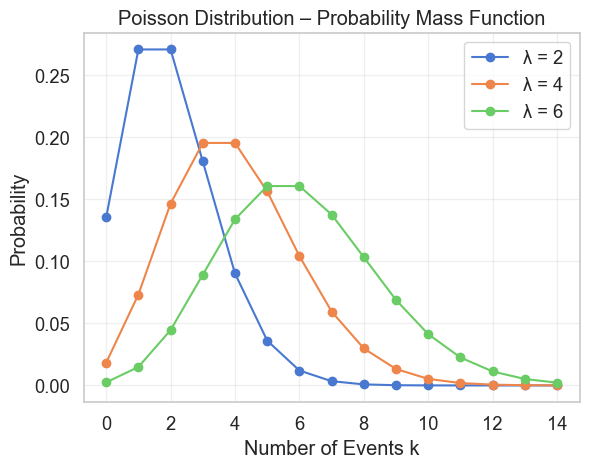

In [15]:
# Specify average event rates (lambda values)
lambdas = [2, 4, 6]

# Define the range of possible event outcomes
k = np.arange(0, 15)

# Print mean and variance for each lambda
for lam in lambdas:
    mean, var = poisson.stats(lam, moments='mv')
    print(f"λ = {lam}: mean = {mean}, variance = {var}")

# Plot the Poisson PMF for different lambda values
plt.figure()

for lam in lambdas:
    pmf = poisson.pmf(k, lam)
    plt.plot(k, pmf, marker='o', linestyle='-', label=f'λ = {lam}')

plt.title('Poisson Distribution – Probability Mass Function')
plt.xlabel('Number of Events k')
plt.ylabel('Probability')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


The previous graph is a visualization of Poisson PMF showing how it changes with different values of rate parameters $\lambda$. Specifically, we tested the parameters:
- $\lambda$ = 2, a low event rate (e.g., 2 customers per hour);
- $\lambda$ = 4, a moderate event rate (e.g., 4 customers per hour);
- $\lambda$ = 6, a higher event rate (e.g., 6 customers per hour).

The PMF is calculated for each value of k (that goes from 0 to 14) to caputre the probability mass for each $\lambda$.

Each curve shows the probability of observing exactly k events, having that the plot shows that as $\lambda$ increses, the distribution shifts to the right (considering that more events are expected) and it becomes more spread out (there's higher variance), and the peak for each distribution (mode) occurs near its $\lambda$ value.

About symmetry, it's visible that:
- $\lambda$ = 2, strongly right-skewed, with a pronounced tail extending to the right;
- $\lambda$ = 4, moderately skewed, becoming more balanced around the mode;
- $\lambda$ = 6, nearly symmetric.

As $\lambda$ increses, the distribution becomes more symmetric and bell-shaped.

### Exponential distribution
The exponential distribution is a continuous probability distribution that models the time between events in a process where events occur continuously and independently at a constant average rate.

A random variable X has an exponential distribution with rate parameter $\lambda > 0$ if:

$$
f(x; \lambda) = \lambda e^{-\lambda x}, \quad x \geq 0
$$

$$
f(x; \lambda) = 0, \quad x < 0
$$
where:
- $\lambda$ is the rate at which events occur per unit time. It must be positive. Higher $\lambda$ means events occur more frequently (shorter waiting times);
- $x$ is the time until next event, it represents waiting time or duration. It's non-negative real numbers $x \in [0, \infty)$.


$\lambda$ controls both the mean and the variance, considering that:

$$E[X] = \frac{1}{\lambda}$$ 
$$Var(X) = \frac{1}{\lambda^2}$$

λ = 0.5: mean = 2.00, variance = 4.00
λ = 1: mean = 1.00, variance = 1.00
λ = 1.5: mean = 0.67, variance = 0.44


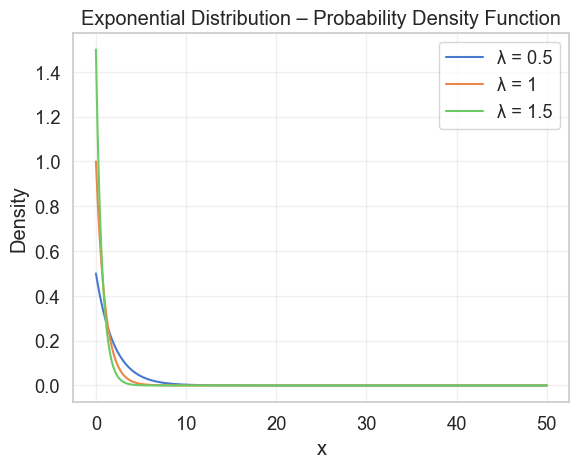

In [109]:
# Specify rate parameters (lambda values)
lambdas = [0.5, 1, 1.5]  # smaller λ = slower decay, larger λ = faster decay

# Define x range for plotting
x = np.linspace(0, 50, 500)

# Print mean and variance for each lambda
for lam in lambdas:
    mean, var = expon.stats(scale=1/lam, moments='mv')  # scale = 1/λ
    print(f"λ = {lam}: mean = {mean:.2f}, variance = {var:.2f}")

# Plot the Exponential PDF for different lambda values
plt.figure()

for lam in lambdas:
    pdf = expon.pdf(x, scale=1/lam)
    plt.plot(x, pdf, label=f'λ = {lam}')

plt.title('Exponential Distribution – Probability Density Function')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


The previous graph is a visualization of Exponential PDF showing how it changes with different values of rate parameters $\lambda$. Specifically, we checked the PDF with $\lambda=0.5, 1, 1.5$ in order to observe how the rate parameter affects the distribution's characteristics:

All curves start at $f(x=0) = \lambda$, having that higher $\lambda$ values have higher initial density. The initial density equals $\lambda$, and this can be verified from the PDF formula:
$$
f(x) = \lambda e^{-\lambda x}
$$
At $x=0$ this simplifies to $f(0)=\lambda$.

The $\lambda$ parameter directly controls how quickly the probability density decreases, having that:
  - $\lambda = 0.5$, slow decay. The  curve decreases gradually and substantial probability mass extends beyond x = 4. There's more probability mass spreading across larger x values, reflecting longer average waiting times (mean = 2.0);
  - $\lambda = 1$, moderate decay. There's a balanced spread of probability, that becomes negligible around $x=4-5$. 
  - $\lambda = 1.5$, rapid decay. It has a steep initial drop. Most probability is concentrated near $x=0$, and it becomes very small by $x=3$, reflecting shorter average waiting times (mean = 0.67).

About spread, considering the variance = $\frac{1}{\lambda^2}$, higher rates produce less variability in waiting times:
  - $\lambda = 0.5$ has the greatest spread, with variance = 4, the heavy tail extending far to the right;
  - $\lambda = 1$ is balanced, with variance = 1;
  - $\lambda = 1.5$ has the least spread, with variance = 0.44, being tightly concentrated near $x=0$.


Unlike the Poisson distribution, which becomes more symmetric as $\lambda$ increases, the Exponential one always maintains its right-skewed, monotonically decreasing shape regardless of $\lambda$. That's because the coefficient of skewness for Exponential distribution is always 2, regardless of $\lambda$, leaving the shape's skewness constant, with only the scale changing. So, while $\lambda$ doesn't change the skewness coefficient, visually lower $\lambda$ appears more skewed because the tail is heavier and extends further and  higher $\lambda$ appears less skewed because the distribution is more compressed.

## Real-World Context

The **Poisson distribution** addresses how often a specific event is likely to happen over a given interval. The interval might represent time (hours, days), space (distance, area), volume, or any measurable parameters. So, it has one key parameter:

$$
\lambda = \text{average rate of occurrence per interval}
$$

It tells how often an event tends to occur and it controls both the mean and the variance of the distribution.

This distribution models seemingly random and irregular events, provided the average rate of occurrence is known and the events are independent of each other.

For example, a customer support center measuring the number of techincal queries received hourly. While these queries may vary significantly from one moment to the next, tracking their average over time allows the Poisson distribution to predict their frequency with remarkable accuracy. If it receives an average of 12 calls per hour, then $\lambda=12$.

Similarly, it can help in different fields:
- *healthcare*, this distribution can help hospitals in estimating how many patients will visit emergency departments on any given day, assisting them in allocating staffing and supplies appropriately;
- *environmental science*, it can help in studying unpredictable natural events such as earthquakes, heavy rainfall, or volcanic eruptions, because these events occur randomly over time or within set regions, making them well-suited for Poisson models;
- *customer experience*, businesses across retail and online platforms rely on the Poisson distribution to forecast customer activity and optimize resources accordingly. For instance, e-commerce companies can estimate peak traffic periods, like during holiday sales, to ensure servers are equipped to handle high demand and prevent downtime;
- *marketing*, it can be used for analyzing the likelihood of responses to promotional campaigns over a fixed period, especially when dealing with rare but significant responses like upsells or cross-sells.



The **Exponential distribution** describes the waiting time between events in a Poisson process. It also uses the same parameter $\lambda$, but its meaning shifts slightely:
$$
\lambda = \text{rate at which events occur in continuous time}
$$
So, $\lambda$ determines how quickly the next event is expected to happen. The mean waiting time is $\frac{1}{\lambda}$, meaning that large $\lambda$ represents events happening quickly (and a short waiting time), while small $\lambda$ represents events happening at a slower pace (and a long waiting time).

This explains why the Exponentian distribution is described as modeling the time until the next arrival in a Poisson process.

For example, it can model the time until a customer arrives at a service point or the lifespan of an electronic component. If the average lifespan of a component is 25 years, then $\lambda=\frac{1}{25}$, since the mean waiting time is $\frac{1}{\lambda}$.

Some fields it can help are:
- *reliability analysis*, this distribution is used to model the time until a mechanical or electronic component fails, assuming a constant failure rate;
- *physics*, it helps calculate the time required for a radioactive particle to decay (radioactive decay) or model the height of molecules in a gas under a uniform gravitational field;
- *healthcare*, especially in survival analysis, it is applied in medical research to estimate the time until specific events, such as disease recurrence or patient survival duration after a particular treatment, assuming a constant hazard rate.


Overall, to understand which distribution is better to use in which case, it's important to have it clear when they come at hand:
- the Poisson distribution is a good option when the goal is to count how many events occur in a fixed interval. So, for example, it finds an answer to questions like how many messages will I receive in the next two hours or how many boxes of milk the supermarket will sell today;
- the Exponential distribution is a better option when the goal is to measure the waiting time until the next event. So, for example, it answers questions like how long will I wait until the next taxi will pass by or how long until this computer fails.

To conclude, if events occur randomly and independently at a constant average rate, then the number of events in an interval follows a Poisson distribution, while the time between events follows an Exponential distribution.


## Relations with Gaussian Probability Model

### Asymptotic relationship between Poisson and Gaussian distributions
The Poisson distribution and the Gaussian probability model are connected through an asymptotic relationship: as the mean parameter $\lambda$ grows, the Poisson distribution becomes increasingly symmetric and continuous‑looking, mirroring the properties of a normal distribution with the same mean and variance.

A Poisson random variable $X \sim Poisson(\lambda)$ can be well‑approximated by a normal distribution:
$$
Y \sim N(\mu=\lambda, \sigma^2=\lambda)
$$
when $\lambda$ is large. This approximation becomes more accurate as $\lambda \to \infty$.

If $X_1$ and $X_2$ are independent Poisson random variables with means $\lambda_1$ and $\lambda_2$:
$$
X_1 + X_2 \sim Poisson(\lambda_1+\lambda_2)
$$
Using the additivity property, any Poisson random variable can be decomposed as a sum of many small independent Poisson components:
$$
X = X_1 + X_2 + \dots + X_N
$$
where each $X_i \sim Poisson(\frac{\lambda}{N})$ with mean $E[X_i]=\frac{\lambda}{N}$ and variance $Var(X_i)=\frac{\lambda}{N}$. As $N$ becomes large, the individual compontents have very small means and variances, but their sum still satisfies $E[X]=\lambda$ and $Var(X)=\lambda$.
By applying the Central Limit Theorem, it shows that X has approximately the same distribution as a normal random variable Y with $E[X]=\lambda$ and $Var(X)=\lambda$, the same mean and variance as X.

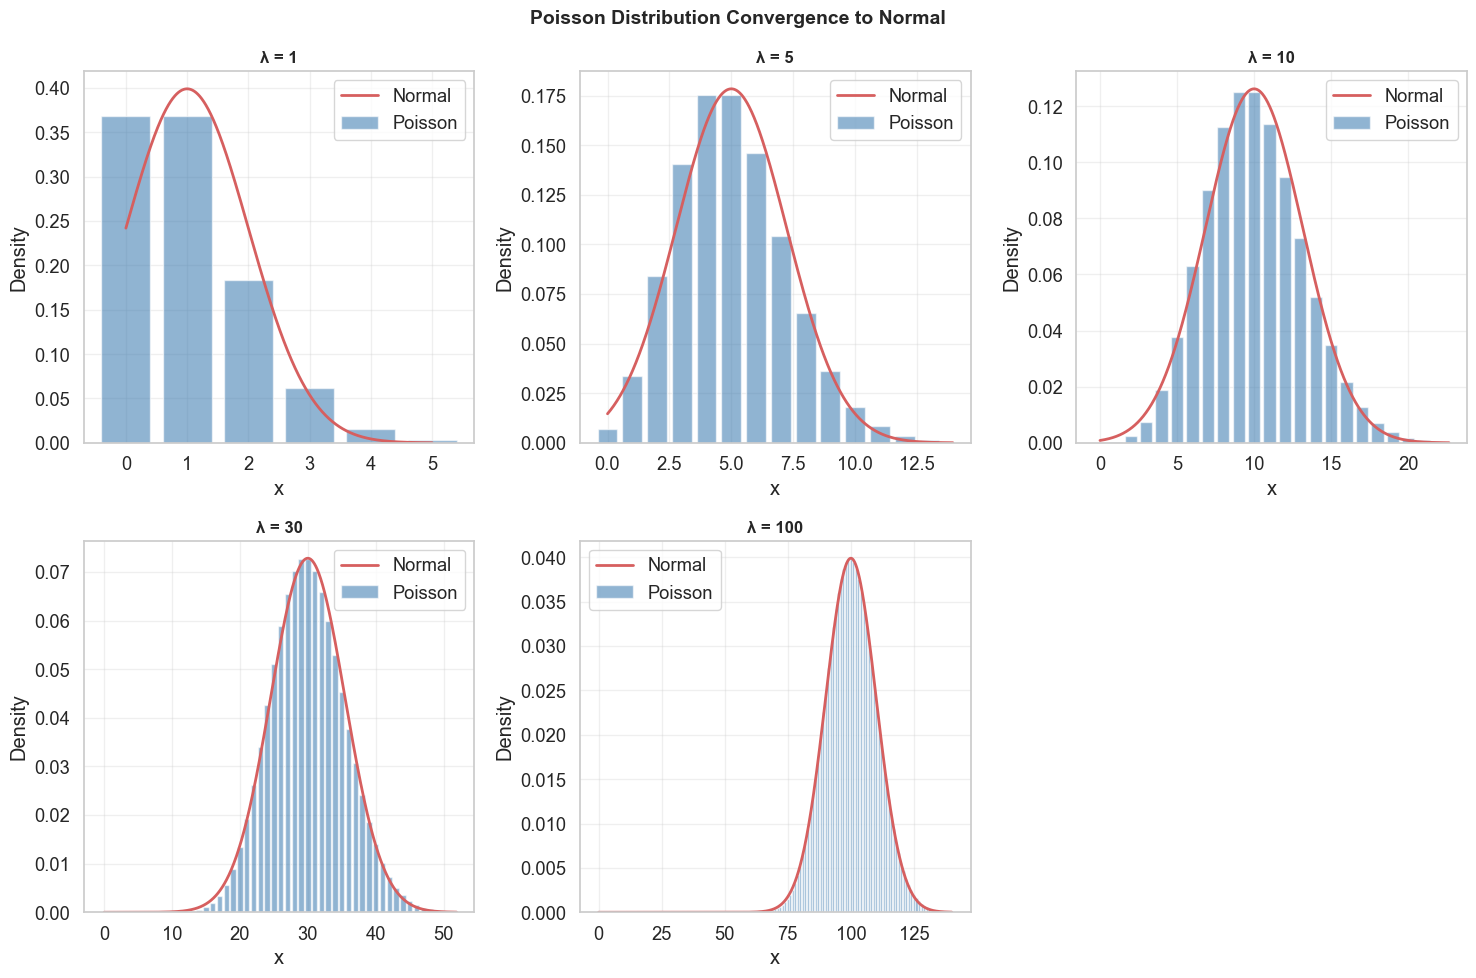

In [22]:
lambdas = [1, 5, 10, 30, 100]
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, lam in enumerate(lambdas):
    ax = axes[i]
    
    # Create range of x values
    x_vals = np.arange(0, int(lam + 4*np.sqrt(lam)) + 1)
    
    # Poisson PMF
    poisson_pmf = poisson.pmf(x_vals, lam)
    
    # Normal PDF
    x_continuous = np.linspace(0, lam + 4*np.sqrt(lam), 1000)
    normal_pdf = norm.pdf(x_continuous, loc=lam, scale=np.sqrt(lam))
    
    # Plot
    ax.bar(x_vals, poisson_pmf, alpha=0.6, color='steelblue', 
           label='Poisson', width=0.8)
    ax.plot(x_continuous, normal_pdf, 'r-', linewidth=2, 
            label='Normal')
    
    ax.set_title(f'λ = {lam}', fontsize=12, fontweight='bold')
    ax.set_xlabel('x')
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Remove extra subplot
axes[-1].axis('off')

plt.suptitle('Poisson Distribution Convergence to Normal', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Relationship between Exponential and Gaussian distributions
The Exponential distribution is not itself Gaussian: it is defined only on $[0, \infty)$ and is strongly right-skewed. This means that, unlike the Poisson distribution, the Exponential one doesn't directly convergence to the Normal distribution though it connects to the Normal distribution through two important pathways: the Gamma distribution and the Central Limit Theorem.


#### Connection via Gamma Distribution
The Exponential distribution is a special case of the Gamma distribution. Specifically, an Exponential random variable with rate $\lambda$ is equivalent to a Gamma random variable with shape parameter $k=1$ and rate parameter $\lambda$:

$$
X \sim Exponential(\lambda) \iff X \sim Gamma(k=1, \text{rate}=\lambda)
$$
If $X_1, X_2, \dots, X_n$ are independent exponential random variables with rate $\lambda$, their sum follows a Gamma distribution:

$$
S_n = X_1 + X_2 + \dots + X_n \sim Gamma(k=n, \text{rate}=\lambda)
$$
with mean $E[S_n] = \frac{n}{\lambda}$ and variance $Var(S_n) = \frac{n}{\lambda^2}$.

As the shape parameter $n$ increases (i.e., as we sum more exponential variables), the Gamma distribution becomes increasingly symmetric and bell-shaped. By the Central Limit Theorem:

$$
S_n \xrightarrow{d} N\left(\frac{n}{\lambda}, \frac{n}{\lambda^2}\right) \quad \text{as } n \to \infty
$$

Or in standardized form:

$$
\frac{S_n - n/\lambda}{\sqrt{n}/\lambda} = \frac{\lambda S_n - n}{\sqrt{n}} \xrightarrow{d} N(0,1) \quad \text{as } n \to \infty
$$

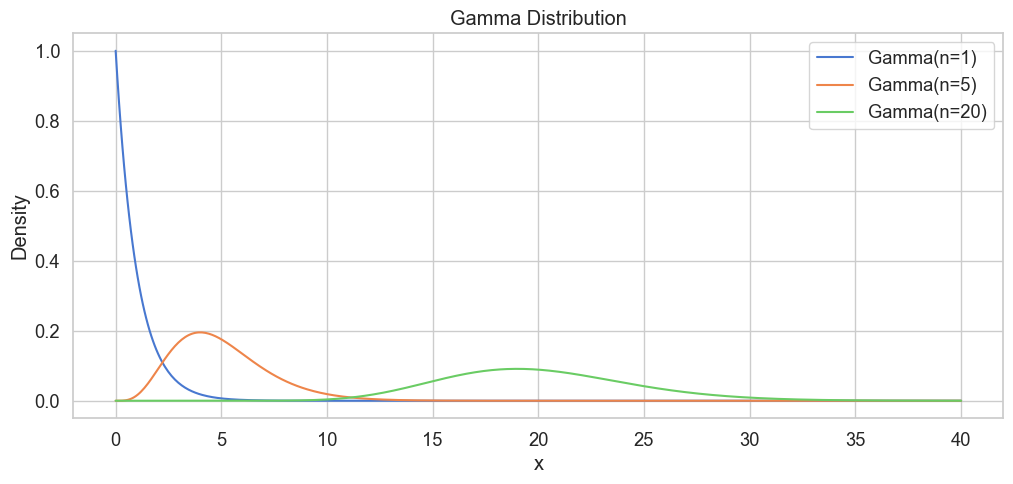

In [57]:
lam = 1
x = np.linspace(0, 40, 500)

plt.figure(figsize=(12, 5))

for n in [1, 5, 20]:
    plt.plot(x, gamma.pdf(x, a=n, scale=1/lam), label=f"Gamma(n={n})")

plt.xlabel("x")
plt.ylabel("Density")
plt.title("Gamma Distribution")
plt.legend()
plt.show()


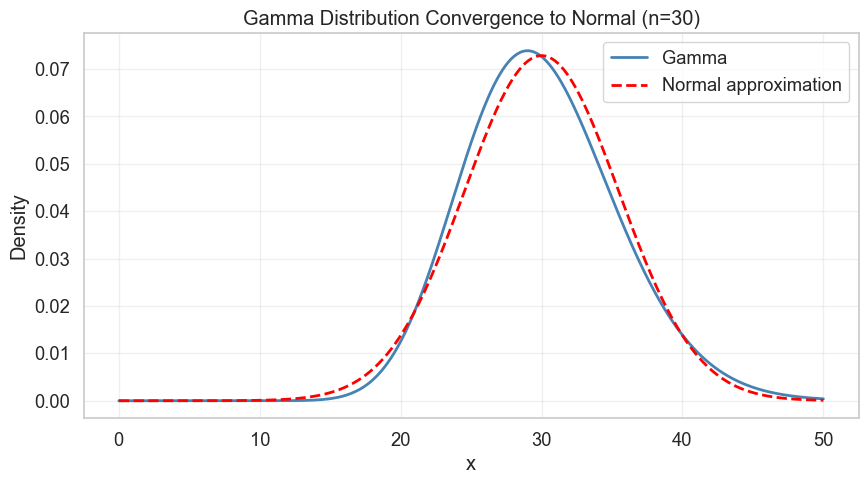

For n=30, Gamma skewness = 0.365 (close to 0 means nearly symmetric)


In [61]:
# Show that large n Gamma distribution is well approximated by Normal
n = 30
lam = 1
x = np.linspace(0, 50, 500)

# Gamma distribution
gamma_pdf = gamma.pdf(x, a=n, scale=1/lam)

# Normal approximation with same mean and variance
mu = n / lam
sigma = np.sqrt(n) / lam
normal_pdf = norm.pdf(x, mu, sigma)

plt.figure(figsize=(10, 5))
plt.plot(x, gamma_pdf, linewidth=2, label=f'Gamma', color='steelblue')
plt.plot(x, normal_pdf, '--', linewidth=2, label=f'Normal approximation', color='red')
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Gamma Distribution Convergence to Normal (n=30)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"For n={n}, Gamma skewness = {2/np.sqrt(n):.3f} (close to 0 means nearly symmetric)")

#### Connection via CLT
More directly, after averaging $n$ independent Exponential($\lambda$) random variables:
$$
\bar{X}_n = \frac{X_1 + X_2 + \dots + X_n}{n}
$$

The Central Limit Theorem guarantees that $\bar{X}_n$ approaches a Normal distribution:
$$
\bar{X}_n \sim N\left(\frac{1}{\lambda}, \frac{1}{n\lambda^2}\right) \quad \text{for large } n
$$

So although individual exponential phenomena are heavily right-skewed, the average across many observations follows an approximately Normal distribution, having that the CLT allows us to apply Normal based statistical methods to averages of non-Normal data.

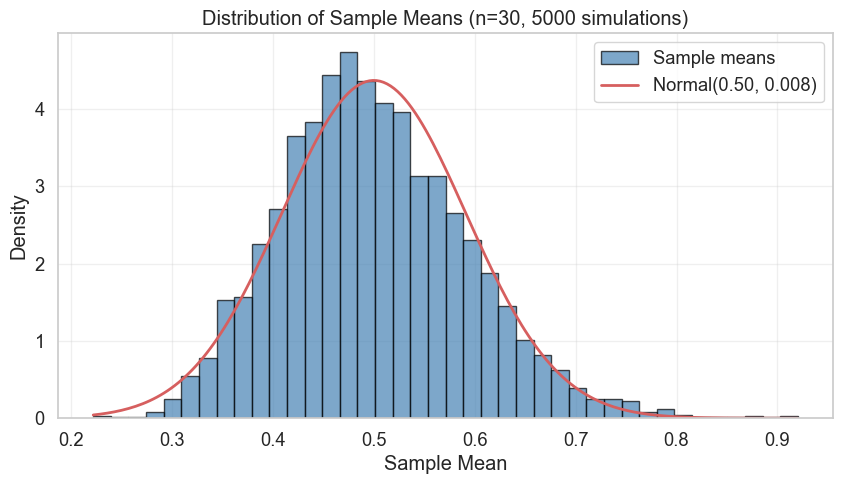

Sample mean of means: 0.500 (theoretical: 0.500)
Sample std of means:  0.092 (theoretical: 0.091)


In [65]:
# Demonstrate CLT
np.random.seed(42)
lam = 2
n = 30  # sample size
n_simulations = 5000

# Generate many sample means
sample_means = [np.random.exponential(1/lam, n).mean() for _ in range(n_simulations)]

# Plot
plt.figure(figsize=(10, 5))
plt.hist(sample_means, bins=40, density=True, alpha=0.7, 
         color='steelblue', edgecolor='black', label='Sample means')

# Overlay theoretical normal
x_range = np.linspace(min(sample_means), max(sample_means), 200)
theoretical_mean = 1/lam
theoretical_std = 1/(lam * np.sqrt(n))
plt.plot(x_range, norm.pdf(x_range, theoretical_mean, theoretical_std), 
         'r-', linewidth=2, label=f'Normal({theoretical_mean:.2f}, {theoretical_std**2:.3f})')

plt.xlabel('Sample Mean')
plt.ylabel('Density')
plt.title(f'Distribution of Sample Means (n={n}, {n_simulations} simulations)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Sample mean of means: {np.mean(sample_means):.3f} (theoretical: {theoretical_mean:.3f})")
print(f"Sample std of means:  {np.std(sample_means):.3f} (theoretical: {theoretical_std:.3f})")

# Section 2 - SIMULATION STUDY
Following the instructions in the assignment, in the this section we generate random samples from both the Poisson and the Exponential distribution using different parameter combinations, then we plot the histograms and density plots, and finally we compare sample mean and variance with the theoretical values.

In [96]:
# Set seed for reproducibility
np.random.seed(42)


# Poisson distribution
poisson_lambdas = [1, 4, 10] 
poisson_samples = {}

print("\n────────────────────────────")
print("Poisson Distribution Results") 
print("────────────────────────────")
for lam in poisson_lambdas:
    samples = np.random.poisson(lam=lam, size=1000)
    poisson_samples[lam] = samples
    print(f"Poisson λ={lam}: mean={samples.mean():.3f}, var={samples.var():.3f}")

# Exponential distribution
exp_rates = [0.5, 1, 2]
exp_samples = {}

print("\n\n────────────────────────────────")
print("Exponential Distribution Results") 
print("────────────────────────────────")
for rate in exp_rates:
    samples = np.random.exponential(scale=1/rate, size=1000)
    exp_samples[rate] = samples
    print(f"Exponential rate λ={rate}: mean={samples.mean():.3f}, var={samples.var():.3f}")



────────────────────────────
Poisson Distribution Results
────────────────────────────
Poisson λ=1: mean=0.975, var=1.024
Poisson λ=4: mean=3.939, var=3.781
Poisson λ=10: mean=10.045, var=9.333


────────────────────────────────
Exponential Distribution Results
────────────────────────────────
Exponential rate λ=0.5: mean=1.969, var=3.830
Exponential rate λ=1: mean=1.003, var=0.871
Exponential rate λ=2: mean=0.525, var=0.310


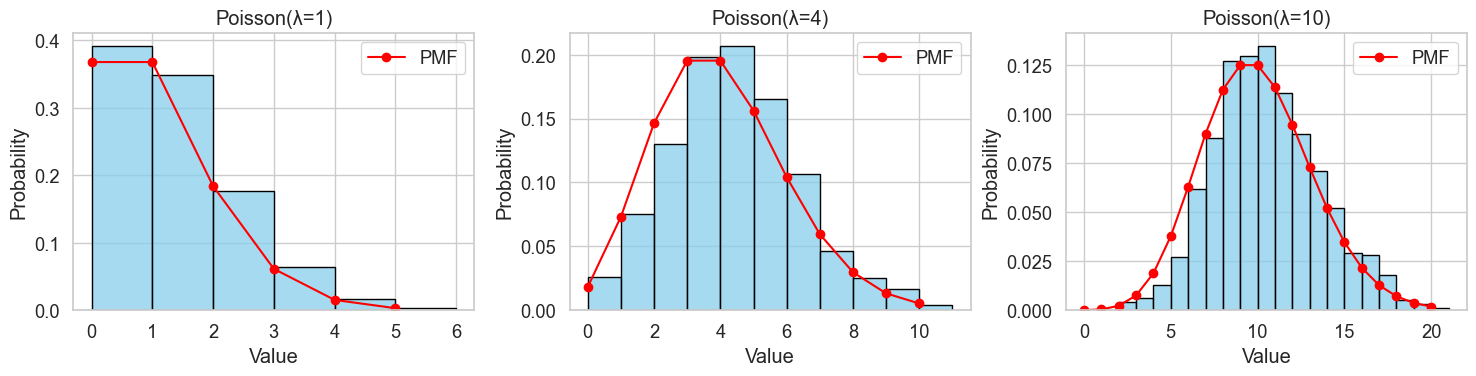

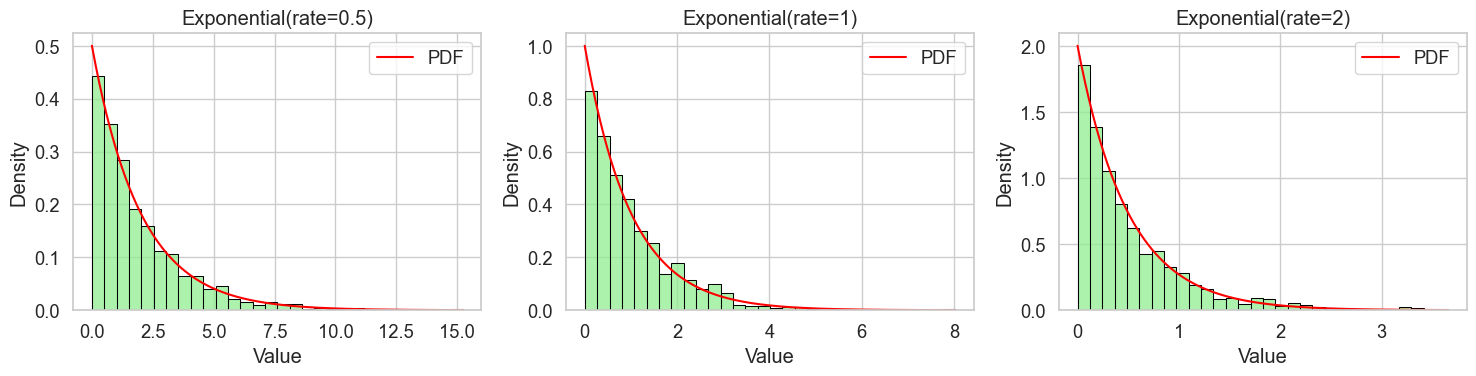

In [30]:
# Plot Poisson histograms and density plots

plt.figure(figsize=(15, 4))

for i, lam in enumerate(poisson_lambdas):
    sample = poisson_samples[lam]

    plt.subplot(1, len(poisson_lambdas), i+1)
    sns.histplot(sample,
                 bins=range(0, max(sample)+2),
                 stat="probability",
                 color="skyblue",
                 edgecolor="black")

    # theoretical PMF
    x_vals = np.arange(0, max(sample)+1)
    pmf_vals = poisson.pmf(x_vals, mu=lam)
    plt.plot(x_vals, pmf_vals, 'o-', color='red', label='PMF')

    plt.title(f"Poisson(λ={lam})")
    plt.xlabel("Value")
    plt.ylabel("Probability")
    plt.legend()

plt.tight_layout()
plt.show()



# Plot Exponential histograms and density plots
plt.figure(figsize=(15, 4))

for i, rate in enumerate(exp_rates):
    sample = exp_samples[rate]

    plt.subplot(1, len(exp_rates), i+1)
    sns.histplot(sample,
                 bins=30,
                 stat="density",
                 color="lightgreen",
                 edgecolor="black")

    # theoretical PDF
    x_vals = np.linspace(0, sample.max(), 200)
    pdf_vals = rate * np.exp(-rate * x_vals)
    plt.plot(x_vals, pdf_vals, color='red', label='PDF')

    plt.title(f"Exponential(rate={rate})")
    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.legend()

plt.tight_layout()
plt.show()


The Poisson distributions behaves as expected theoretically: the histrograms demostrate the convergence to the Normal distribution as $\lambda$ increases, while for small $\lambda$ the distribution is right-skewed.

The Exponential distributions too are consistent with the theory, showing that the distribution keeps its right-skewed shape regardless of $\lambda$, going through spread changes only.

In [32]:
print("\n--- Poisson: Sample vs Theoretical Moments ---")
for lam, sample in poisson_samples.items():
    sample_mean = sample.mean()
    sample_var = sample.var()

    theo_mean = lam
    theo_var = lam

    print(f"\nλ = {lam}")
    print(f"  Sample mean: {sample_mean:.4f}   |  Theoretical mean: {theo_mean}")
    print(f"  Sample var : {sample_var:.4f}   |  Theoretical var : {theo_var}")


print("\n--- Exponential: Sample vs Theoretical Moments ---")
for rate, sample in exp_samples.items():
    sample_mean = sample.mean()
    sample_var = sample.var()

    theo_mean = 1 / rate
    theo_var = 1 / (rate**2)

    print(f"\nRate λ = {rate}")
    print(f"  Sample mean: {sample_mean:.3f}   |  Theoretical mean: {theo_mean:.3f}")
    print(f"  Sample var : {sample_var:.3f}   |  Theoretical var : {theo_var:.3f}")



--- Poisson: Sample vs Theoretical Moments ---

λ = 1
  Sample mean: 0.9750   |  Theoretical mean: 1
  Sample var : 1.0244   |  Theoretical var : 1

λ = 4
  Sample mean: 3.9390   |  Theoretical mean: 4
  Sample var : 3.7813   |  Theoretical var : 4

λ = 10
  Sample mean: 10.0450   |  Theoretical mean: 10
  Sample var : 9.3330   |  Theoretical var : 10

--- Exponential: Sample vs Theoretical Moments ---

Rate λ = 0.5
  Sample mean: 1.969   |  Theoretical mean: 2.000
  Sample var : 3.830   |  Theoretical var : 4.000

Rate λ = 1
  Sample mean: 1.003   |  Theoretical mean: 1.000
  Sample var : 0.871   |  Theoretical var : 1.000

Rate λ = 2
  Sample mean: 0.525   |  Theoretical mean: 0.500
  Sample var : 0.310   |  Theoretical var : 0.250


For the Poisson distribution, as observed for the graphs too, the empirical results are consistent with everything said till now, having just small errors that are well within expected sampling variation (it ranges from 0.4% to 7%), confirming that $E[X]=Var[X]=\lambda$.

For the Exponential one, the statistics aligns well too with theory, especially with mean estimates showing strong agreement while there's a larger variability in variance (error between 4.3% in $\lambda=0.5$ and 24% for $\lambda=2$), occurring for a variaty of reasons, especially because variance amplifies the influence of extreme values and the Exponential distribution is highly right-skewed.

Overall, these results validate that our simulated data behaves according to the theoretical probability models, demonstrating the Law of Large Numbers in action.

# Section 3 - APPLICATION SCENARIO

## Hypothetical context: cybersecurity intrusion attempts
Let's consider a tech company running an online service that is constantly exposed to cyberattacks.  

The security team has noticed that during night hours (between midnight and 6:00 AM), when most legitimate users are asleep, the system receives a steady stream of suspicious login attempts from automated bots trying to break into user accounts. 

The security team wants to understand the pattern of these attacks to better allocate monitoring resources and set up appropriate alert thresholds. They decide to model the attack pattern during the night shift, when the attack rate is relatively stable and not influenced by legitimate user activity.

We focus on a night‑shift monitoring window (e.g., 00:00–06:00), where attacks are frequent but relatively stable in rate, considering the Poisson random variable 𝑋 representing the number of intrusion attempts in one hour and the Exponential one 𝑇 as time (in minutes) between consecutive intrusion attempts.

### Poisson model for hourly intrusion counts
The model $X \sim Poisson(\lambda)$ have $\lambda$ has the average number of intrusion attempts per hour.

We made some assumptions:
- intrusion attempts are independent;
- the rate of attempts is approximately constant over the night‑shift window;
- events are counted in a fixed time interval (1 hour);
- the probability of more than one attempt in a very small time interval is negligible.

So, suppose $\lambda=5$ then, on average, there are 5 intrusion attempts per hour.

### Exponential model for time between attempts
The model $T \sim Exponential(\lambda)$ has the same rate $\lambda=5$ attempts/hour.

The assamptions are:
- interarrival times are independent;
- the process is memoryless, so the probability that an attack occurs in the next minute does not depend on how long it has been since the last one;
- the arrival process is a Poisson process, which implies exponential interarrival times.

So, with $\lambda=5$ per hour, the ean interarrival time is $E[T]=\frac{1}{\lambda}=\frac{1}{5} \text{hours}=12 \text{minutes}$.

### Simulation
We’ll simulate:
- 1000 hours of monitoring, so hourly counts of intrusion attempts (Poisson);
- 1000 interarrival times between attempts (Exponential).

Then we’ll compute sample mean and variance and compare to theoretical values and make histograms with theoretical overlays.

--- Hourly intrusion attempts (Poisson) --- 
Sample mean: 5.037   | Theoretical mean: 5.000
Sample var : 5.298   | Theoretical var : 5.000

--- Interarrival times (Exponential) ---
Sample mean: 0.2173 h | Theoretical mean: 0.2000 h
Sample var : 0.0505 h² | Theoretical var : 0.0400 h²





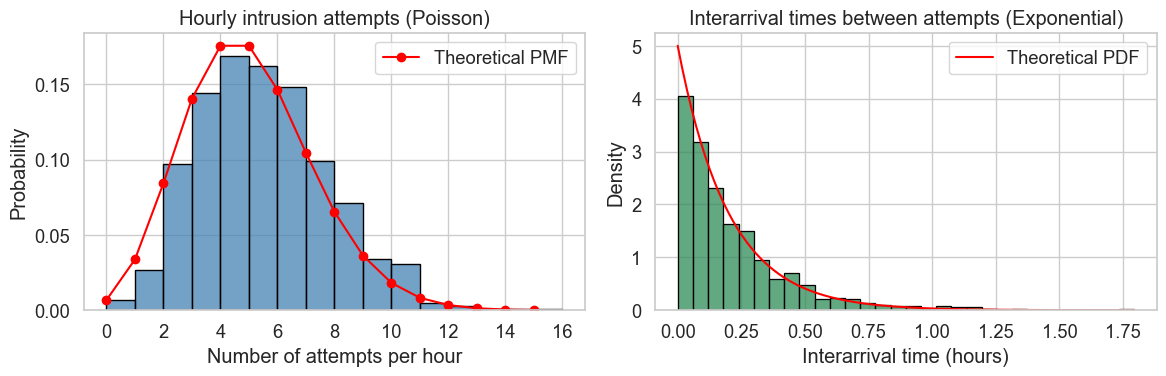

In [103]:
lambda_attacks = 5      # average intrusion attempts per hour
n_hours = 1000          # number of hours to simulate
n_interarrivals = 1000  # number of interarrival times to simulate


# Hourly counts of intrusion attempts (Poisson)
hourly_attacks = np.random.poisson(lam=lambda_attacks, size=n_hours)

# Interarrival times between attempts (Exponential)
# rate = 5 per hour -> scale = 1/5 hours
interarrival_times = np.random.exponential(scale=1/lambda_attacks, size=n_interarrivals)


# Poisson (hourly counts)
att_mean_sample = hourly_attacks.mean()
att_var_sample = hourly_attacks.var()
att_mean_theo = lambda_attacks
att_var_theo = lambda_attacks

# Exponential (interarrival times)
ia_mean_sample = interarrival_times.mean()
ia_var_sample = interarrival_times.var()
ia_mean_theo = 1 / lambda_attacks
ia_var_theo = 1 / (lambda_attacks**2)

print("--- Hourly intrusion attempts (Poisson) --- ")
print(f"Sample mean: {att_mean_sample:.3f}   | Theoretical mean: {att_mean_theo:.3f}")
print(f"Sample var : {att_var_sample:.3f}   | Theoretical var : {att_var_theo:.3f}")

print("\n--- Interarrival times (Exponential) ---")
print(f"Sample mean: {ia_mean_sample:.4f} h | Theoretical mean: {ia_mean_theo:.4f} h")
print(f"Sample var : {ia_var_sample:.4f} h² | Theoretical var : {ia_var_theo:.4f} h²")
print("\n\n")

# Visualization of the simulated data
plt.figure(figsize=(12, 4))

# Histogram for hourly attacks (Poisson)
plt.subplot(1, 2, 1)
sns.histplot(hourly_attacks,
             bins=range(0, hourly_attacks.max()+2),
             stat="probability",
             color="steelblue",
             edgecolor="black")

x_vals = np.arange(0, hourly_attacks.max()+1)
pmf_vals = poisson.pmf(x_vals, mu=lambda_attacks)
plt.plot(x_vals, pmf_vals, 'o-', color='red', label='Theoretical PMF')

plt.title("Hourly intrusion attempts (Poisson)")
plt.xlabel("Number of attempts per hour")
plt.ylabel("Probability")
plt.legend()

# Histogram for interarrival times (Exponential)
plt.subplot(1, 2, 2)
sns.histplot(interarrival_times,
             bins=30,
             stat="density",
             color="seagreen",
             edgecolor="black")

x_vals = np.linspace(0, interarrival_times.max(), 200)
pdf_vals = lambda_attacks * np.exp(-lambda_attacks * x_vals)
plt.plot(x_vals, pdf_vals, color='red', label='Theoretical PDF')

plt.title("Interarrival times between attempts (Exponential)")
plt.xlabel("Interarrival time (hours)")
plt.ylabel("Density")
plt.legend()

plt.tight_layout()
plt.show()


### Conclusions
This modeling approach helps the security team quantify and anticipate intrusion patterns, allowing better resource allocation and alert timing during vulnerable hours. 

The Poisson model closely matches the theoretical mean and variance, validating the assumption of a stable hourly attack rate, while the Exponential model shows slightly higher sample mean and variance than expected, which may reflect natural variability or minor deviations from the memoryless assumption.

Both histograms align well with their theoretical overlays, confirming that the simulated data behaves as predicted by the chosen distributions.